# Prepare the Workplace
You should upload the "Colab Notebooks" folder to the **root directory** of your Google Drive before proceeding.

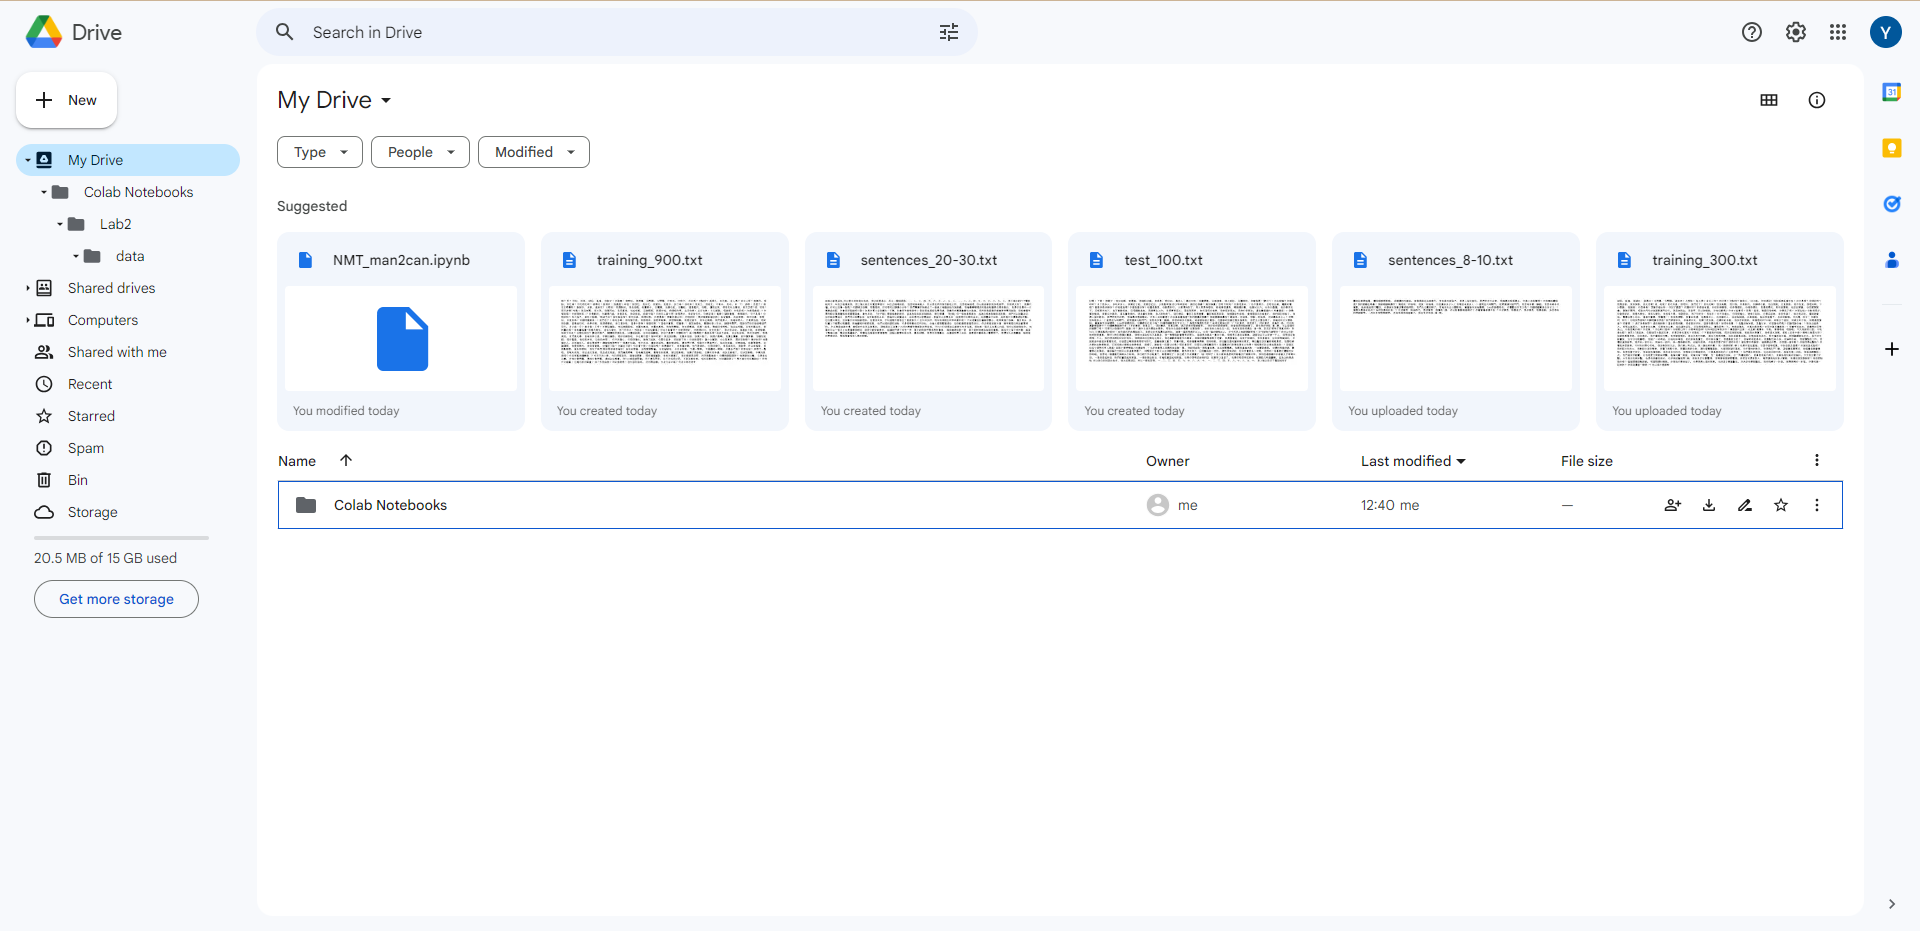

## Corrected notebook
This cleaned version uses the current tokenizer call interface, returns attention masks and labels from `TranslationDataset`, ignores target padding during loss calculation, and saves both the model and tokenizer. Old execution outputs have been removed.


In [40]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/My Drive/Colab Notebooks/Lab2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/Colab Notebooks/Lab2


# Install Necessary Libraries and Import a Pre-trained Model


In [41]:
!pip install transformers

In [42]:
import numpy as np
import os
import pytz
import random
import shutil
import torch
import tqdm.notebook as tq
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import BartForConditionalGeneration, \
BertTokenizer, get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'GPU Available: {torch.cuda.is_available()}')

GPU Available: True


In [43]:
tokenizer = BertTokenizer.from_pretrained("fnlp/bart-base-chinese")
model = BartForConditionalGeneration.from_pretrained("fnlp/bart-base-chinese")
model = model.to(device)

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

# Load the Dataset for Training your Model

In [44]:
training_index = '300'
# 'training_index' implies how many sentences will be used for training.
# Replace the above number with '300' or '900' to decide how much data
# you would like to use to train your model.

x_train = []
y_train = []

open_dir_front = '/content/drive/MyDrive/Colab Notebooks/Lab2/data/training_'
open_dir_end = '.txt'
open_dir = '%s%s%s'%(open_dir_front, training_index, open_dir_end)

with open(open_dir, 'r') as f:
  for line in f:
    line = line.strip().split('\t')
    x_train.append(line[0])
    y_train.append(line[1])

Display some random sentences from the loaded dataset. You can run the below cell repeatedly to display different sentences.

In [45]:
random_indices = random.sample(range(len(x_train)), k=10)
# 'k' implies how many sentences will be displayed each time.
# You can modify the number to display more or less sentences.

print('Sample training data:\n')
for index in random_indices:
  print('Man: %s'%(x_train[index]))
  print('Can: %s\n'%(y_train[index]))

Sample training data:

Man: 我無法相信自己的眼睛。
Can: 我以為自己睇錯。

Man: 昨晚他的車被偷了。
Can: 佢尋晚俾人偷咗架車。

Man: 我父親在電力公司工作。
Can: 我老豆喺電力公司度做嘢。

Man: 我要用魔法把他變成一隻青蛙！
Can: 我要用魔法將佢變做一隻青蛙！

Man: Tom決定了留下來。
Can: Tom決定咗留低。

Man: 要不是他這麼磨磨蹭蹭，現在早做完了。
Can: 如果佢唔係嗮咗咁多時間，佢一早就已經做完啦。

Man: 你想找哪個方面的工作？
Can: 你想搵咩方面嘅工？

Man: 他很容易覺得累。
Can: 佢好易攰。

Man: 我有很多事想做，但就是沒時間做。
Can: 我有好多嘢想做，但係就係無時間做。

Man: 她晚了起牀。
Can: 佢晏咗起身。



You can select and copy from the above sentences to **[Bing Microsoft Translator](https://www.bing.com/translator?from=yue&setlang=en)** to translate Mandarin or Cantonese sentences to English if you wish.

Notice that current Cantonese translators are not as accurate as Chinese translators, so the translation results are **for reference only** and **should not be used as the only means** to determine the whether an output is correct or not.

In [46]:
MAX_LENGTH = 25
# Sentences longer than 25 tokens (including special tokens) are truncated.
# Shorter sentences are padded to MAX_LENGTH.

class TranslationDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data
    self.tokenizer = tokenizer

  def __getitem__(self, index):
    source, target = self.data[index]

    source_encoding = self.tokenizer(
        source,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    target_encoding = self.tokenizer(
        target,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    # Remove only the tokenizer's leading singleton dimension.
    input_ids = source_encoding['input_ids'].squeeze(0)
    attention_mask = source_encoding['attention_mask'].squeeze(0)
    labels = target_encoding['input_ids'].squeeze(0)

    # Hugging Face models ignore label positions set to -100.
    labels[labels == self.tokenizer.pad_token_id] = -100

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

  def __len__(self):
    return len(self.data)


dataset = TranslationDataset(list(zip(x_train, y_train)), tokenizer)

# Verify the dataset structure before creating the DataLoader.
sample = dataset[0]
print('Dataset size:', len(dataset))
print('Input shape:', sample['input_ids'].shape)
print('Attention-mask shape:', sample['attention_mask'].shape)
print('Label shape:', sample['labels'].shape)


Dataset size: 300
Input shape: torch.Size([25])
Attention-mask shape: torch.Size([25])
Label shape: torch.Size([25])


# Tokenisation

A sentence can be tokenised to a series of numbers and recovered from them using a tokeniser. Those processes are called "encoding" and "decoding". The below cell displays the encoded numbers and decoded results of a random sentence from the training dataset. You can also repeatedly run the below cell to see the demonstration in different sentences or sentences specified by yourself.

In [47]:
# random_index = random.choice(range(len(x_train)))
# x = x_train[random_index]

x = "然後我很快就睡著了。"

# You can place another sentence in the above double quotes "" to
# see the encoded and decoded results of the sentence you specified.

print(f'A sample Chinese sentence:\n{x}\n')

encoded = tokenizer(x, max_length=MAX_LENGTH, padding='max_length',
                                truncation=True, return_tensors='pt')
input_ids = encoded["input_ids"].tolist()[0]
print(f'Encode the sentence (a list of characters)\
into a list of input ids:\n{input_ids}\n')

decoded = tokenizer.decode(input_ids)
print(f'Decode a list of input ids back to a list of characters:\n{decoded}')

A sample Chinese sentence:
然後我很快就睡著了。

Encode the sentence (a list of characters)into a list of input ids:
[101, 13792, 9331, 9970, 9327, 9425, 8485, 15348, 18616, 5028, 3566, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Decode a list of input ids back to a list of characters:
[CLS] 然 後 我 很 快 就 睡 著 了 。 [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


Again, you can select and copy from the above sentences to **[Bing Microsoft Translator](https://www.bing.com/translator?from=yue&setlang=en)** to translate Mandarin or Cantonese sentences to English **for reference only** if you wish.

# Fine-tuning

In [48]:
BATCH_SIZE = 16
data_loader = DataLoader(dataset=dataset, batch_size=BATCH_SIZE, shuffle=True)

LEARNING_RATE = 2e-5
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

NUM_EPOCHS = 20
total_steps = len(data_loader) * NUM_EPOCHS

scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                            num_training_steps=total_steps)

In [49]:
def train(model, data_loader, optimizer, device, num_epochs, scheduler,
          saved_model, tokenizer):
  model.train()
  training_losses = []

  for epoch in range(num_epochs):
    print('-' * 100)
    print(f'Epoch {epoch + 1}/{num_epochs}')
    total_loss = 0.0

    progress_bar = tq.tqdm(data_loader, desc=f'Epoch {epoch + 1}', leave=True)

    for batch in progress_bar:
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['labels'].to(device)

      optimizer.zero_grad(set_to_none=True)

      outputs = model(
          input_ids=input_ids,
          attention_mask=attention_mask,
          labels=labels
      )

      loss = outputs.loss
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

      optimizer.step()
      scheduler.step()

      total_loss += loss.item()
      progress_bar.set_postfix(loss=f'{loss.item():.4f}')

    avg_train_loss = total_loss / len(data_loader)
    training_losses.append(avg_train_loss)
    print(f'Average training loss: {avg_train_loss:.4f}')
    print('-' * 100)

  os.makedirs(saved_model, exist_ok=True)
  model.save_pretrained(saved_model)
  tokenizer.save_pretrained(saved_model)
  np.save(os.path.join(saved_model, 'training_losses.npy'),
          np.array(training_losses))

  print(f'Model and tokenizer saved at folder {saved_model}.')
  print('-' * 100)

  return training_losses


In [50]:
# Set the directory for saving your trained model

training_index = '300'
# 'training_index' implies how many sentences will be used for training.
# Replace the above number with '300' or '900' to decide how much data
# you would like to use to train your model.

saved_model_front = "/content/drive/MyDrive/Colab Notebooks/Lab2/final_model_"
saved_model = '%s%s'%(saved_model_front, training_index)

# Start training

training_losses = train(
    model, data_loader, optimizer, device, NUM_EPOCHS, scheduler,
    saved_model, tokenizer
)

----------------------------------------------------------------------------------------------------
Epoch 1/20


Epoch 1:   0%|          | 0/19 [00:00<?, ?it/s]

Average training loss: 3.5172
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Epoch 2/20


Epoch 2:   0%|          | 0/19 [00:00<?, ?it/s]

Average training loss: 2.5150
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Epoch 3/20


...

Average training loss: 0.3815
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Epoch 20/20


Epoch 20:   0%|          | 0/19 [00:00<?, ?it/s]

Average training loss: 0.3738
----------------------------------------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved at folder /content/drive/MyDrive/Colab Notebooks/Lab2/final_model_300.
----------------------------------------------------------------------------------------------------


# Evaluation

In [51]:
# test_sentence = "我們昨天不在家。" # We were not at home yesterday.
# reference = "我哋尋日唔喺屋企。" # We were not at home yesterday.

# test_sentence = "然後我很快就睡著了。" # After that, I soon fell asleep.
# reference = "跟住我好快就瞓著咗喇。" # After that, I soon fell asleep.

test_sentence = "她是一個非常美的女人。" # She is a very beautiful woman.
reference = "佢係一個好靚嘅女人。" # She is a very beautiful woman.

Again, you can select and copy from the above sentences to **[Bing Microsoft Translator](https://www.bing.com/translator?from=yue&setlang=en)** to translate Mandarin or Cantonese sentences to English **for reference only** if you wish.

In [52]:
def translate_sentence(sentence, model, tokenizer, device, max_length):
  model = model.to(device)
  model.eval()

  tokens = tokenizer(sentence, max_length=max_length,
            padding='max_length', truncation=True,
            return_tensors='pt')

  input_ids = tokens["input_ids"].to(device)
  attention_mask = tokens["attention_mask"].to(device)

  with torch.no_grad():
    outputs = model.generate(input_ids=input_ids,
                             attention_mask=attention_mask,
                             max_length=max_length)

  output_sentence = tokenizer.decode(outputs[0], skip_special_tokens=True)

  return output_sentence

In [53]:
# Specify the pre-trained model you want to use.

pretrained_model = BartForConditionalGeneration.\
from_pretrained("fnlp/bart-base-chinese")

# Specify the directory of your fine-tuned model to load.

training_index = '300'
saved_model_front = "/content/drive/MyDrive/Colab Notebooks/Lab2/final_model_"
saved_model = '%s%s'%(saved_model_front, training_index)

final_model = BartForConditionalGeneration.\
from_pretrained(saved_model)

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Before fine-tuning:

In [54]:
translation = translate_sentence(test_sentence, pretrained_model,
                                 tokenizer, device, MAX_LENGTH)
translation = ' '.join(list(translation)).split()
print("Translation:", ''.join(translation))

score = sentence_bleu([list(reference)], translation,
                      smoothing_function=SmoothingFunction().method4)
print("BLEU score:", score)

Translation: 她是一個非常美的女人。
BLEU score: 0.1459819203086565


After fine-tuning:

In [55]:
translation = translate_sentence(test_sentence, final_model,
                                 tokenizer, device, MAX_LENGTH)
translation = ' '.join(list(translation)).split()
print("Translation:", ''.join(translation))

score = sentence_bleu([list(reference)], translation,
                      smoothing_function=SmoothingFunction().method4)
print("BLEU score:", score)

Translation: 佢係一個好靚嘅女人。
BLEU score: 1.0


Again, you can select and copy from the above sentences to **[Bing Microsoft Translator](https://www.bing.com/translator?from=yue&setlang=en)** to translate Mandarin or Cantonese sentences to English **for reference only** if you wish.

**Computing the average BLEU score of the pre-trained model on the test set:**

In [56]:
bleu_score_list = []

with open("/content/drive/MyDrive/Colab Notebooks/Lab2/data/test_100.txt",
          'r') as f:
  for line in f:
    line = line.strip().split('\t')
    test_sentence = line[0]
    reference = line[1]

    translation = translate_sentence(test_sentence, pretrained_model,
                                     tokenizer, device, MAX_LENGTH)
    translation = ' '.join(list(translation)).split()

    score = sentence_bleu([list(reference)], translation,
                          smoothing_function=SmoothingFunction().method4)
    bleu_score_list.append(score)

print("Average BLEU score of {0} sentences: {1}".\
      format(len(bleu_score_list), np.mean(bleu_score_list)))

Average BLEU score of 100 sentences: 0.16467238396311945


**Computing the average BLEU score of the fine-tuned model on the test set:**

In [57]:
bleu_score_list = []

with open("/content/drive/MyDrive/Colab Notebooks/Lab2/data/test_100.txt",
          'r') as f:
  for line in f:
    line = line.strip().split('\t')
    test_sentence = line[0]
    reference = line[1]

    translation = translate_sentence(test_sentence, final_model,
                                     tokenizer, device, MAX_LENGTH)
    translation = ' '.join(list(translation)).split()

    score = sentence_bleu([list(reference)], translation,
                          smoothing_function=SmoothingFunction().method4)
    bleu_score_list.append(score)

print("Average BLEU score of {0} sentences: {1}".\
      format(len(bleu_score_list), np.mean(bleu_score_list)))

Average BLEU score of 100 sentences: 0.3102183073602159


In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Computing the average BLEU score of the fine-tuned model on other sets:**



In [59]:
bleu_score_list = []

with open("/content/drive/MyDrive/Colab Notebooks/Lab2/data/\
sentences_8-10.txt",'r') as f:
  for line in f:
    line = line.strip().split('\t')
    test_sentence = line[0]
    reference = line[1]

    translation = translate_sentence(test_sentence, final_model,
                                     tokenizer, device, MAX_LENGTH)
    translation = ' '.join(list(translation)).split()

    score = sentence_bleu([list(reference)], translation,
                          smoothing_function=SmoothingFunction().method4)
    bleu_score_list.append(score)

print("Average BLEU score of {0} sentences: {1}".\
      format(len(bleu_score_list), np.mean(bleu_score_list)))

Average BLEU score of 20 sentences: 0.23578793480261212


# Fine-tuning with Another Training Set

In [60]:
tokenizer = BertTokenizer.from_pretrained("fnlp/bart-base-chinese")
model = BartForConditionalGeneration.from_pretrained("fnlp/bart-base-chinese")
model = model.to(device)

training_index = '900'
# 'training_index' implies how many sentences will be used for training.
# Replace the above number with '300' or '900' to decide how much data
# you would like to use to train your model.

x_train = []
y_train = []

open_dir_front = '/content/drive/MyDrive/Colab Notebooks/Lab2/data/training_'
open_dir_end = '.txt'
open_dir = '%s%s%s'%(open_dir_front, training_index, open_dir_end)

with open(open_dir, 'r') as f:
  for line in f:
    line = line.strip().split('\t')
    x_train.append(line[0])
    y_train.append(line[1])

dataset = TranslationDataset(list(zip(x_train, y_train)), tokenizer)

saved_model_front = "/content/drive/MyDrive/Colab Notebooks/Lab2/final_model_"
saved_model = '%s%s'%(saved_model_front, training_index)

# Define training parameters

BATCH_SIZE = 16
data_loader = DataLoader(dataset=dataset, batch_size=BATCH_SIZE, shuffle=True)

LEARNING_RATE = 2e-5
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

NUM_EPOCHS = 20
total_steps = len(data_loader) * NUM_EPOCHS

scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                            num_training_steps=total_steps)

# Start training

training_losses = train(
    model, data_loader, optimizer, device, NUM_EPOCHS, scheduler,
    saved_model, tokenizer
)

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

----------------------------------------------------------------------------------------------------
Epoch 1/20


Epoch 1:   0%|          | 0/57 [00:00<?, ?it/s]

Average training loss: 2.8680
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Epoch 2/20


Epoch 2:   0%|          | 0/57 [00:00<?, ?it/s]

...

Average training loss: 0.2334
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Epoch 20/20


Epoch 20:   0%|          | 0/57 [00:00<?, ?it/s]

Average training loss: 0.2208
----------------------------------------------------------------------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved at folder /content/drive/MyDrive/Colab Notebooks/Lab2/final_model_900.
----------------------------------------------------------------------------------------------------


In [61]:
# Specify the pre-trained model you want to use.

pretrained_model = BartForConditionalGeneration.\
from_pretrained("fnlp/bart-base-chinese")

# Specify the directory of your fine-tuned model to load.

training_index = '900'
saved_model_front = "/content/drive/MyDrive/Colab Notebooks/Lab2/final_model_"
saved_model = '%s%s'%(saved_model_front, training_index)

final_model = BartForConditionalGeneration.\
from_pretrained(saved_model)

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

In [62]:
# test_sentence = "我們昨天不在家。" # We were not at home yesterday.
# reference = "我哋尋日唔喺屋企。" # We were not at home yesterday.

# test_sentence = "然後我很快就睡著了。" # After that, I soon fell asleep.
# reference = "跟住我好快就瞓著咗喇。" # After that, I soon fell asleep.

test_sentence = "她是一個非常美的女人。" # She is a very beautiful woman.
reference = "佢係一個好靚嘅女人。" # She is a very beautiful woman.

Again, you can select and copy from the above sentences to **[Bing Microsoft Translator](https://www.bing.com/translator?from=yue&setlang=en)** to translate Mandarin or Cantonese sentences to English **for reference only** if you wish.

In [63]:
translation = translate_sentence(test_sentence, pretrained_model,
                                 tokenizer, device, MAX_LENGTH)
translation = ' '.join(list(translation)).split()
print("Translation:", ''.join(translation))

score = sentence_bleu([list(reference)], translation,
                      smoothing_function=SmoothingFunction().method4)
print("BLEU score:", score)

Translation: 她是一個非常美的女人。
BLEU score: 0.1459819203086565


In [64]:
translation = translate_sentence(test_sentence, final_model,
                                 tokenizer, device, MAX_LENGTH)
translation = ' '.join(list(translation)).split()
print("Translation:", ''.join(translation))

score = sentence_bleu([list(reference)], translation,
                      smoothing_function=SmoothingFunction().method4)
print("BLEU score:", score)

Translation: 佢係一個好靚嘅女人。
BLEU score: 1.0


Again, you can select and copy from the above sentences to **[Bing Microsoft Translator](https://www.bing.com/translator?from=yue&setlang=en)** to translate Mandarin or Cantonese sentences to English **for reference only** if you wish.

**Computing the average BLEU score of the fine-tuned model on the test set:**

In [65]:
bleu_score_list = []

with open("/content/drive/MyDrive/Colab Notebooks/Lab2/data/test_100.txt",
          'r') as f:
  for line in f:
    line = line.strip().split('\t')
    test_sentence = line[0]
    reference = line[1]

    translation = translate_sentence(test_sentence, final_model,
                                     tokenizer, device, MAX_LENGTH)
    translation = ' '.join(list(translation)).split()

    score = sentence_bleu([list(reference)], translation,
                          smoothing_function=SmoothingFunction().method4)
    bleu_score_list.append(score)

print("Average BLEU score of {0} sentences: {1}".\
      format(len(bleu_score_list), np.mean(bleu_score_list)))

Average BLEU score of 100 sentences: 0.40117800398078246
